2.1 Panorama general

En esta sección vas a aprender a explorar distribuciones con Seaborn usando tres enfoques complementarios:

Histogramas con histplot.
Curvas de densidad (KDE) con kdeplot.
Combinaciones histograma + KDE, ya sea superpuestos o con ejes independientes.
Todos los ejemplos están listos para copiar y pegar: incluyen los imports necesarios, configuran un tema agradable y muestran cómo complementar el resultado con funciones de Matplotlib.

2.2 Histogramas con histplot

El histograma agrupa valores en bins (intervalos) y cuenta cuántos registros caen en cada uno. Es el primer gráfico para detectar la forma de la distribución.

A) Histograma básico

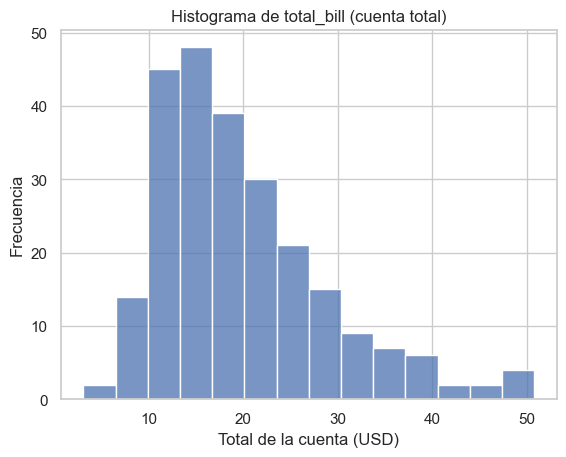

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tema visual recomendado
sns.set_theme(style="whitegrid", context="notebook")

# Dataset de ejemplo
tips = sns.load_dataset("tips")

# Histograma simple de la cuenta total
sns.histplot(data=tips, x="total_bill")
plt.title("Histograma de total_bill (cuenta total)")
plt.xlabel("Total de la cuenta (USD)")
plt.ylabel("Frecuencia")
plt.show()

B) Control de bins y escala
Parámetros clave para afinar el histograma:

bins: cantidad de barras (o estrategias como "auto", "sturges").
binwidth: ancho de cada barra, útil cuando la unidad tiene sentido (por ejemplo, 2 USD).
stat: métrica del eje Y ("count", "frequency", "density", "probability").
log_scale: escala logarítmica para colas largas.

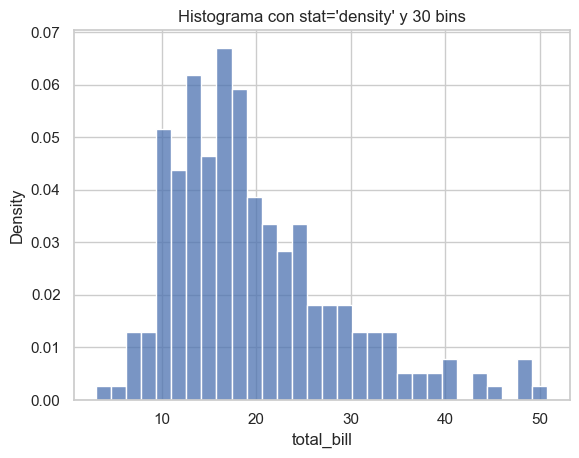

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.histplot(
    data=tips,
    x="total_bill",
    bins=30,            # o binwidth=2
    stat="density",     # count | frequency | density | probability
    element="bars"      # bars | step | poly
)
plt.title("Histograma con stat='density' y 30 bins")
plt.show()

C) Variables categóricas con hue y múltiples series
El parámetro hue colorea por categoría y multiple define cómo se combinan las series.

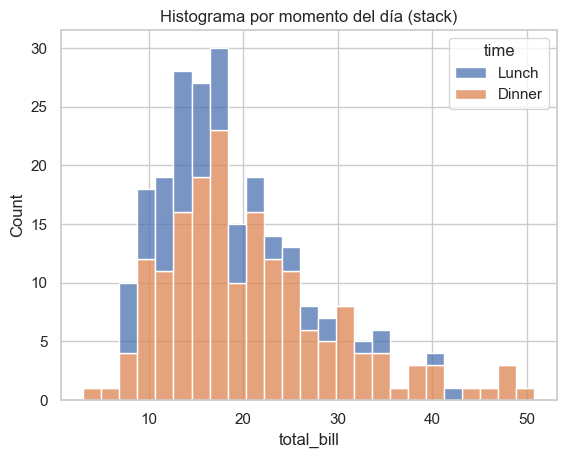

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.histplot(
    data=tips,
    x="total_bill",
    hue="time",         # Lunch vs Dinner
    element="bars",
    multiple="stack",   # layer | stack | dodge | fill
    bins=25,
    stat="count"
)
plt.title("Histograma por momento del día (stack)")
plt.show()

D) Distribuciones discretas (enteros)
Para datos enteros (por ejemplo, cantidad de comensales) indicá discrete=True o definí binwidth=1.

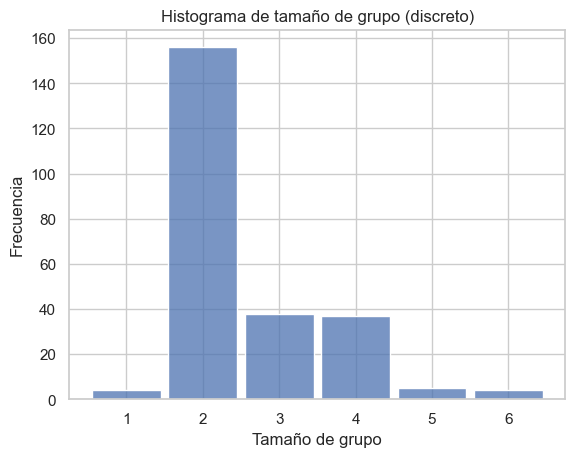

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.histplot(
    data=tips,
    x="size",           # tamaño de grupo (entero)
    discrete=True,
    shrink=0.9
)
plt.title("Histograma de tamaño de grupo (discreto)")
plt.xlabel("Tamaño de grupo")
plt.ylabel("Frecuencia")
plt.show()

E) Distribución acumulada
cumulative=True genera la función de distribución acumulada (CDF).

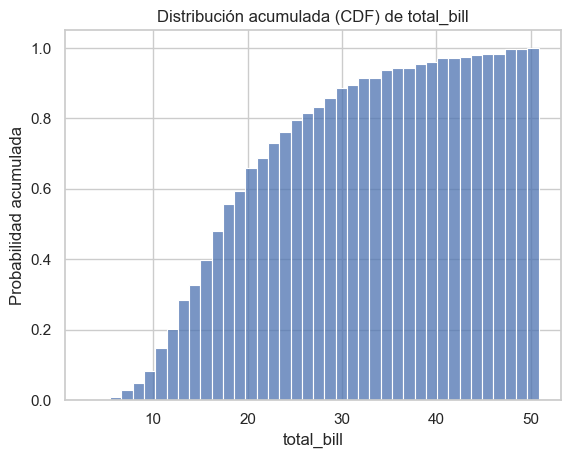

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.histplot(
    data=tips,
    x="total_bill",
    bins=40,
    stat="probability",
    cumulative=True
)
plt.title("Distribución acumulada (CDF) de total_bill")
plt.ylabel("Probabilidad acumulada")
plt.show()

2.3 Distribuciones suavizadas con kdeplot
La KDE (Kernel Density Estimation) estima una densidad continua y suavizada, ideal para ver la forma de la distribución sin depender de los bins.

A) KDE básica

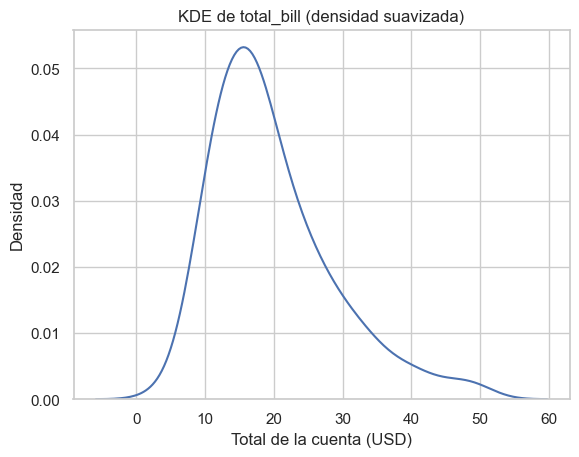

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.kdeplot(data=tips, x="total_bill")
plt.title("KDE de total_bill (densidad suavizada)")
plt.xlabel("Total de la cuenta (USD)")
plt.ylabel("Densidad")
plt.show()

B) Relleno de la curva y suavidad
Activá fill=True para rellenar bajo la curva y ajustá bw_adjust para controlar la suavidad (valores mayores generan curvas más suaves).

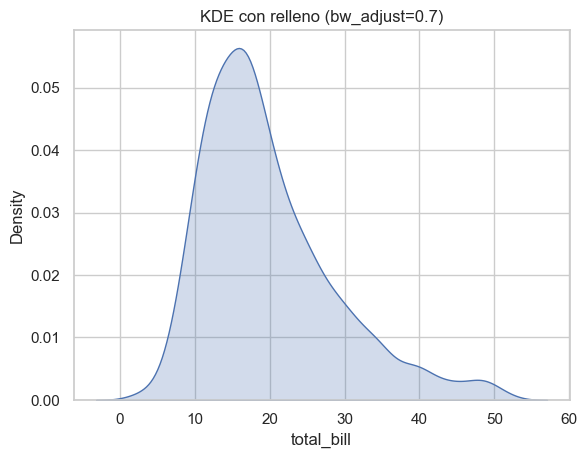

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.kdeplot(data=tips, x="total_bill", fill=True, bw_adjust=0.7)
plt.title("KDE con relleno (bw_adjust=0.7)")
plt.show()

C) Múltiples KDE por categoría
El parámetro hue superpone o separa densidades por grupo, mientras que common_norm=False evita normalizarlas juntas.

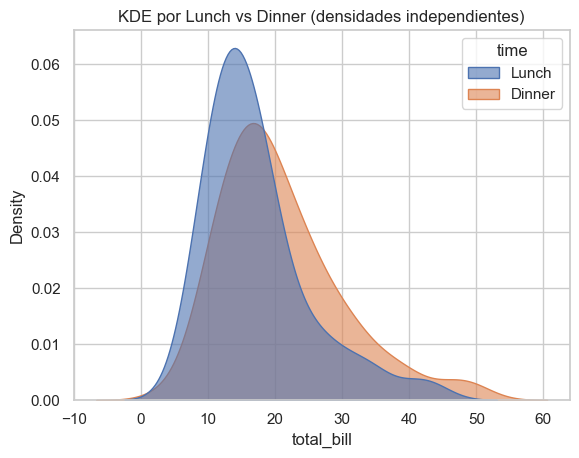

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="time",
    fill=True,
    common_norm=False,   # densidades independientes
    alpha=0.6
)
plt.title("KDE por Lunch vs Dinner (densidades independientes)")
plt.show()

D) KDE acumulada (CDF continua)

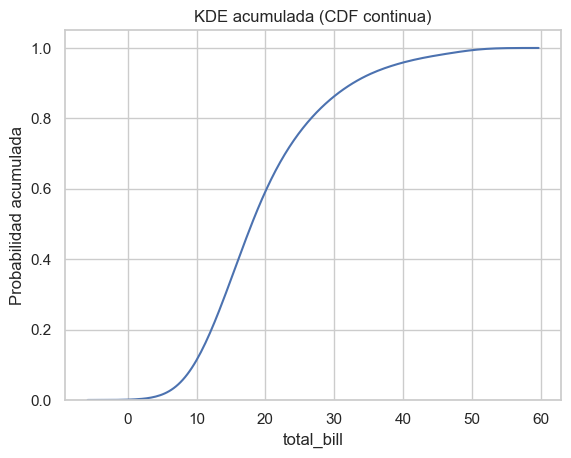

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.kdeplot(data=tips, x="total_bill", cumulative=True)
plt.title("KDE acumulada (CDF continua)")
plt.ylabel("Probabilidad acumulada")
plt.show()

Sugerencia: evitá KDE con variables muy discretas o con pocos datos. En esos casos, preferí histogramas con discrete=True o binwidth específico.

2.4 Combinación de histograma y KDE
Podés superponer un histograma (frecuencias/bins) y una KDE (forma suavizada). Existen dos enfoques principales: superposición en el mismo eje o visualización con doble eje.

A) Superposición simple (mismo eje)

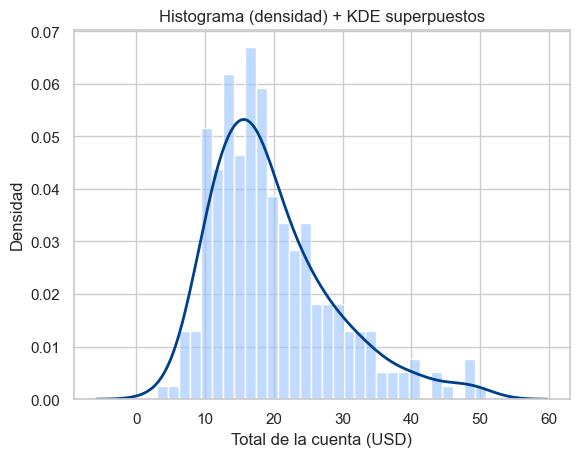

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

ax = sns.histplot(
    data=tips, x="total_bill",
    bins=30, stat="density", color="#99c2ff", alpha=0.6, edgecolor=None
)
sns.kdeplot(
    data=tips, x="total_bill",
    color="#003f8c", linewidth=2, ax=ax
)

plt.title("Histograma (densidad) + KDE superpuestos")
plt.xlabel("Total de la cuenta (USD)")
plt.ylabel("Densidad")
plt.show()

B) Histograma porcentual por categoría + KDE global

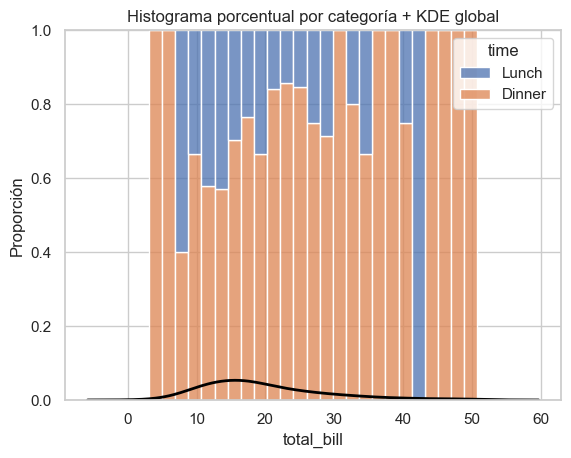

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

# Histograma porcentual por categoría (rellena 100%)
ax = sns.histplot(
    data=tips, x="total_bill", hue="time",
    multiple="fill", element="bars", bins=25
)

# KDE global encima (solo para mostrar la forma general)
sns.kdeplot(data=tips, x="total_bill", color="black", linewidth=2, ax=ax)

plt.title("Histograma porcentual por categoría + KDE global")
plt.ylabel("Proporción")
plt.show()

C) Doble eje: barras a la izquierda y KDE a la derecha
Usá doble eje cuando la escala del histograma difiere mucho de la densidad.

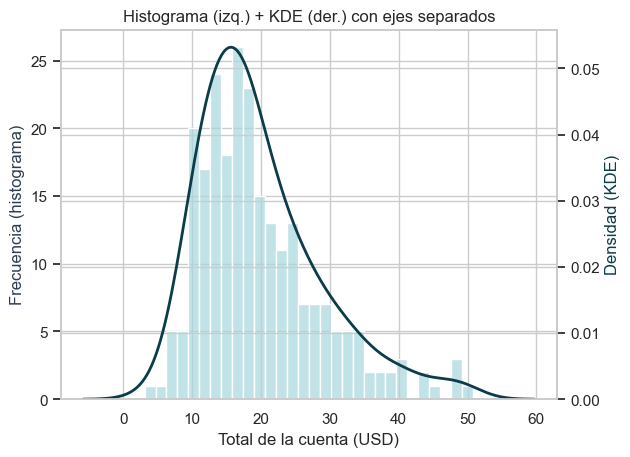

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

fig, ax1 = plt.subplots()

# Histograma en eje izquierdo
sns.histplot(
    data=tips, x="total_bill",
    bins=30, color="#a7d8de", alpha=0.7, ax=ax1
)
ax1.set_xlabel("Total de la cuenta (USD)")
ax1.set_ylabel("Frecuencia (histograma)", color="#2c3e50")

# Crear eje derecho para KDE
ax2 = ax1.twinx()
sns.kdeplot(
    data=tips, x="total_bill",
    color="#0b3c49", linewidth=2, ax=ax2
)
ax2.set_ylabel("Densidad (KDE)", color="#0b3c49")

plt.title("Histograma (izq.) + KDE (der.) con ejes separados")
plt.show()

2.5 Consejos prácticos y errores comunes
Elegí stat con intención: "count" para volúmenes absolutos, "density" si vas a superponer KDE y "probability" para interpretar proporciones.

No abuses de los bins: muy pocos ocultan la forma; demasiados introducen ruido. Probá con binwidth cuando la unidad tenga sentido.

Para categorías: multiple="fill" compara proporciones, "stack" suma volúmenes y "dodge" muestra barras lado a lado.

KDE y outliers: ajustá bw_adjust (por ejemplo, 0.5, 0.8, 1.2) para evitar curvas demasiado onduladas o planas.

Datos discretos: preferí histogramas discretos; la KDE puede inventar continuidad donde no la hay.

Documentá tus decisiones: explicar por qué usaste density, probability, 
multiple, etc., mejora la comunicación con tu audiencia.

Mini-checklist
¿Tu variable es continua? Histograma + KDE superpuestos.

¿Comparás categorías? Usá hue y multiple (fill/stack/dodge).

¿Querés proporciones? Elegí stat="probability" o multiple="fill".
 
¿La forma se ve rara? Ajustá bins, binwidth o bw_adjust.